# Exploration: Turnout Times
**TURNOUT TIMES**

---

**Zweck:** Die Ausrückzeiten je Wache und Quartal durchleuchten und einordnen, welchen Teil der Antwortzeit sie erklären können.  
**Input:** `stg_turnout_times`, `fct_turnout_times_quarterly` und `stg_missions` aus `data/berlin_emergency.duckdb`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen; Hinweis, welche Anreicherung (Wachen-Koordinaten) fehlt.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

## Structure

### Periods and Stations

Pro Wache und Quartal eine Zeile, dazu ein rollierender Snapshot (`current`, letzte 30 Tage). Laut Feldbeschreibung der BF zählen nur Alarmierungen auf der Wache für Einsätze mit hoher Dringlichkeit, bei denen das Fahrzeug ausgerückt ist; Alarmierungen der Freiwilligen Feuerwehr sind entfernt. `mittlere_ausrueckedauer` ist der Mittelwert der Alarmierungsübernahmezeiten (Sekunden), also die Zeit von der Alarmierung bis zur Übernahme durch die Besatzung.

In [2]:
df_periods = q("""
    select period, period_type, count(*) as stations, min(period_start) as start, max(period_end) as end,
           count(mean_turnout_seconds_rtw) as with_rtw, count(mean_turnout_seconds_nef) as with_nef, count(mean_turnout_seconds_lhf) as with_lhf,
           count(mean_turnout_seconds_dlk) as with_dlk, count(mean_turnout_seconds_elw) as with_elw
    from stg_turnout_times group by 1, 2 order by min(period_start), period_type
""")
show_df(df_periods)

,period,period_type,stations,start,end,with_rtw,with_nef,with_lhf,with_dlk,with_elw
0,2018_q1,quarter,67,2018-01-01 00:00:00,2018-03-31 00:00:00,67,22,35,28,14
1,2018_q2,quarter,70,2018-04-01 00:00:00,2018-06-30 00:00:00,70,23,35,28,14
2,2018_q3,quarter,69,2018-07-01 00:00:00,2018-09-30 00:00:00,69,23,35,28,14
3,2018_q4,quarter,71,2018-10-01 00:00:00,2018-12-31 00:00:00,71,23,35,28,14
4,2019_q1,quarter,68,2019-01-01 00:00:00,2019-03-31 00:00:00,68,22,35,28,15
5,2019_q2,quarter,69,2019-04-01 00:00:00,2019-06-30 00:00:00,69,22,35,28,12
6,2019_q3,quarter,69,2019-07-01 00:00:00,2019-09-30 00:00:00,69,22,35,28,14
7,2019_q4,quarter,70,2019-10-01 00:00:00,2019-12-31 00:00:00,70,22,35,28,12
8,2020_q1,quarter,70,2020-01-01 00:00:00,2020-03-31 00:00:00,70,22,35,28,15
9,2020_q2,quarter,73,2020-04-01 00:00:00,2020-06-30 00:00:00,72,23,35,28,13


Das letzte Quartal ist angebrochen und enthält nur Daten bis zum Ladedatum; es darf nicht mit vollen Quartalen verglichen werden.

### Station Identity

In [3]:
df_ids = q("""
    select count(distinct station_id) as station_ids, count(distinct station_name) as station_names, count(*) as rows_total
    from stg_turnout_times
""")
show_df(df_ids)
df_name_change = q("""
    select station_id, count(distinct station_name) as names, min(station_name) as first_name, max(station_name) as other_name
    from stg_turnout_times group by 1 having count(distinct station_name) > 1 order by 1
""")
show_df(df_name_change)

,station_ids,station_names,rows_total
0,80,80,2675


,station_id,names,first_name,other_name
0,1100,2,Feuer- und Lehrrettungswache Mitte,Mitte
1,3608,2,TXL,TXL/Charlottenburg Nord
2,3690,2,Siemensstadt,Siemensstadt/Charlottenburg Nord


In [4]:
df_life = q("""
    select station_id, any_value(station_name) as station_name, min(period) as first_period, max(period) as last_period, count(*) as periods
    from stg_turnout_times where period_type = 'quarter' group by 1
    having count(*) < (select count(distinct period) from stg_turnout_times where period_type = 'quarter') order by periods
""")
show_df(df_life.head(15))

,station_id,station_name,first_period,last_period,periods
0,6600,Hohenschönhausen,2026_q2,2026_q4,3
1,2202,Schönholz,2022_q4,2023_q3,4
2,2402,Konradshöhe,2026_q1,2026_q4,4
3,6407,Sana Klinikum Lichtenberg,2018_q2,2023_q2,6
4,3608,TXL,2023_q1,2025_q4,12
5,1704,Scharnhorststraße,2018_q4,2025_q3,18
6,1110,Mitte,2018_q1,2026_q1,19
7,3103,Lynar,2021_q2,2026_q4,23
8,3503,Budapester,2021_q1,2026_q4,24
9,3600,Charlottenburg-Nord,2018_q1,2026_q4,24


## Missing Values


───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,2531,
1,columns,17,
2,duplicates,0,0.0%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,mean_turnout_seconds_elw,2044,80.76%
1,alarm_count_elw,2044,80.76%
2,alarm_count_nef,1645,64.99%
3,mean_turnout_seconds_nef,1645,64.99%
4,mean_turnout_seconds_dlk,1550,61.24%
5,alarm_count_dlk,1550,61.24%
6,mean_turnout_seconds_lhf,1318,52.07%
7,alarm_count_lhf,1318,52.07%
8,mean_turnout_seconds_rtw,2,0.08%
9,alarm_count_rtw,2,0.08%


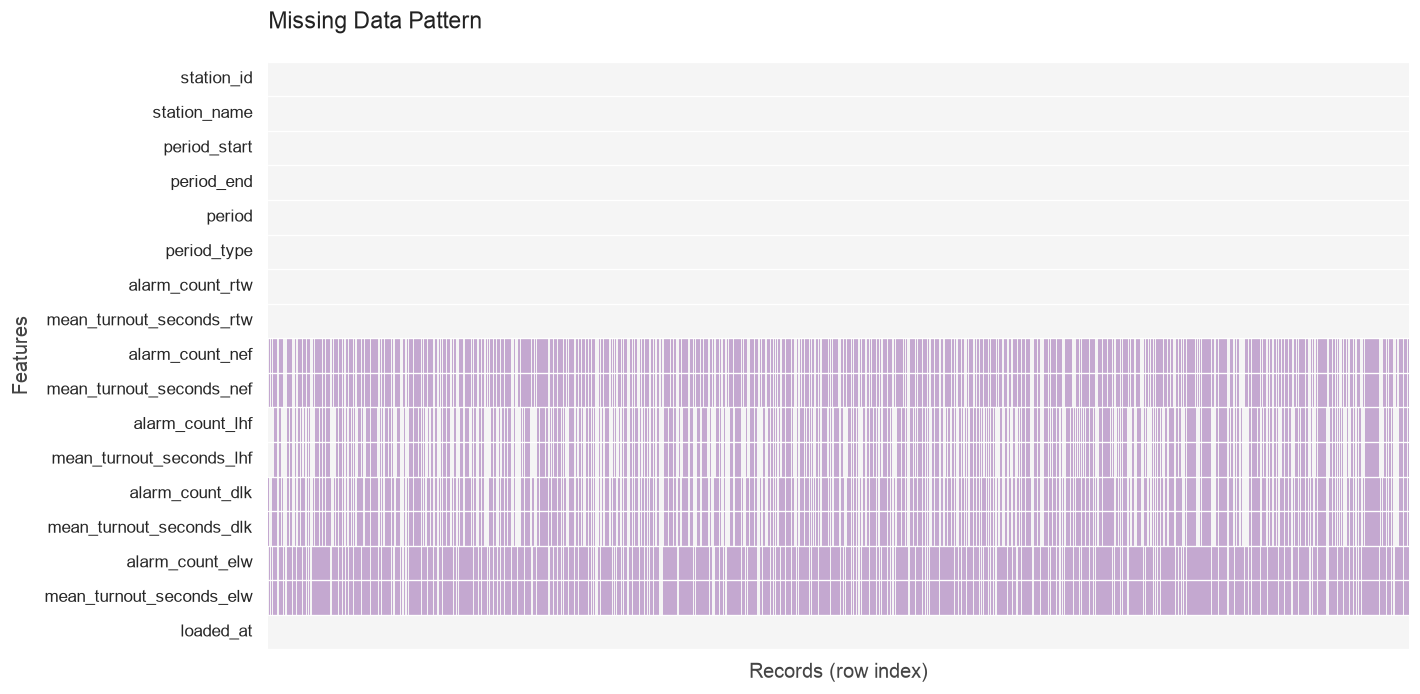

In [5]:
df_t = q("select * from stg_turnout_times where period_type = 'quarter' and period_end < current_date")
inspect(df_t, sections=['dimensions', 'missing'])

Fehlende Werte sind hier Struktur: Eine Wache ohne NEF, Drehleiter oder ELW hat in der Spalte keinen Wert. Anzahl Wachen je Fahrzeugtyp (volle Quartale):

In [6]:
df_fleet = q("""
    select period,
           count(alarm_count_rtw) as rtw, count(alarm_count_nef) as nef, count(alarm_count_lhf) as lhf,
           count(alarm_count_dlk) as dlk, count(alarm_count_elw) as elw
    from stg_turnout_times where period_type = 'quarter' and period_end < current_date
    group by 1 order by 1
""")
show_df(df_fleet.iloc[[0, 4, 8, 12, 16, 20, 24, -1]])

,period,rtw,nef,lhf,dlk,elw
0,2018_q1,67,22,35,28,14
4,2019_q1,68,22,35,28,15
8,2020_q1,70,22,35,28,15
12,2021_q1,72,26,34,28,15
16,2022_q1,74,27,34,28,15
20,2023_q1,77,28,36,28,14
24,2024_q1,73,27,35,28,15
34,2026_q3,73,25,36,30,13


## Turnout Time

### By Year and Vehicle Type

Jahreswerte als mit den Alarmierungen gewichteter Mittelwert über alle Wachen (volle Quartale).

unit,year,DLK,ELW,LHF,NEF,RTW
0,2018,129.10,91.70,104.90,87.60,88.50
1,2019,128.70,89.10,100.30,83.80,85.60
2,2020,118.10,81.80,90.70,75.70,80.40
3,2021,116.60,90.60,93.60,77.60,82.60
4,2022,116.20,90.60,93.60,79.20,83.60
5,2023,115.60,89.40,93.90,79.50,82.50
6,2024,116.50,91.50,92.80,80.60,82.70
7,2025,109.70,89.90,89.60,80.20,82.70
8,2026,104.10,91.70,80.90,77.00,79.40


Text(0, 0.5, 'seconds')

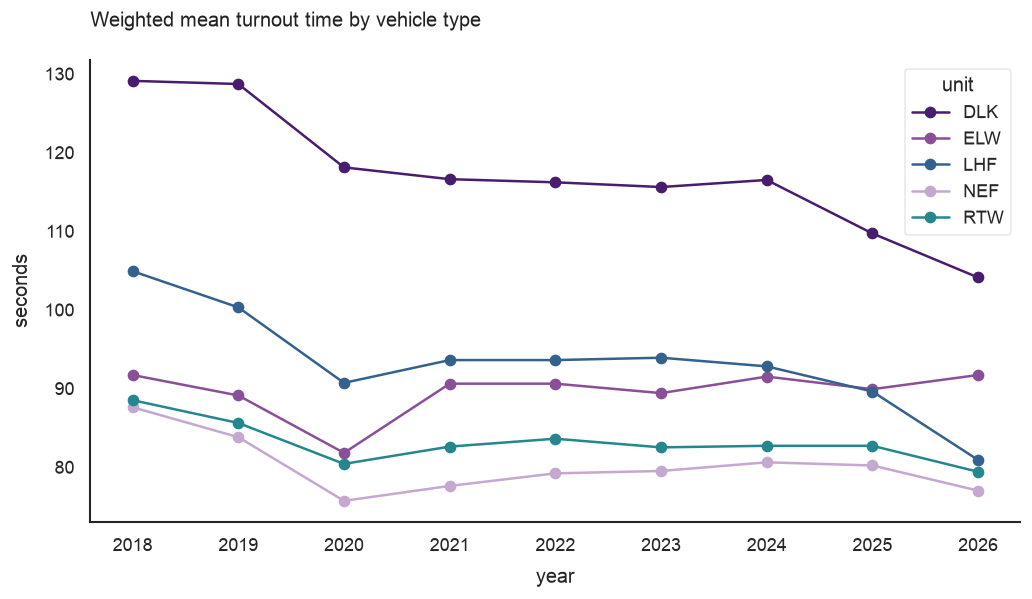

In [7]:
def weighted_year(unit: str) -> str:
    return (f"select year(period_start) as year, '{unit.upper()}' as unit, sum(alarm_count_{unit}) as alarms, "
            f"round(sum(alarm_count_{unit} * mean_turnout_seconds_{unit}) / sum(alarm_count_{unit}), 1) as mean_turnout_s "
            f"from stg_turnout_times where period_type = 'quarter' and period_end < current_date and alarm_count_{unit} > 0 group by 1")

df_year = q(' union all '.join(weighted_year(u) for u in ['rtw', 'nef', 'lhf', 'dlk', 'elw']) + ' order by 2, 1')
df_year_wide = df_year.pivot(index='year', columns='unit', values='mean_turnout_s')
show_df(df_year_wide.reset_index())
ax = df_year_wide.plot(figsize=(10, 5), title='Weighted mean turnout time by vehicle type', marker='o')
ax.set_ylabel('seconds')

In [8]:
show_df(df_year.pivot(index='year', columns='unit', values='alarms').reset_index())

unit,year,DLK,ELW,LHF,NEF,RTW
0,2018,12054.00,10935.00,60602.00,77396.00,304906.00
1,2019,10047.00,10862.00,53977.00,77320.00,305700.00
2,2020,9947.00,11293.00,50336.00,70894.00,283498.00
3,2021,10307.00,12161.00,56799.00,76786.00,293771.00
4,2022,10969.00,12124.00,65114.00,86917.00,319195.00
5,2023,10605.00,11755.00,59825.00,78286.00,328559.00
6,2024,10163.00,11577.00,58636.00,72340.00,341841.00
7,2025,10125.00,11265.00,57816.00,68521.00,243862.00
8,2026,7731.00,9075.00,43631.00,47411.00,147799.00


### Between Stations

In [9]:
df_st = q("""
    select station_id, any_value(station_name) as station_name, sum(alarm_count_rtw) as rtw_alarms,
           round(sum(alarm_count_rtw * mean_turnout_seconds_rtw) / sum(alarm_count_rtw), 1) as rtw_turnout_s
    from stg_turnout_times where period_type = 'quarter' and period_start >= '2025-01-01' and period_end < current_date and alarm_count_rtw > 0
    group by 1 having sum(alarm_count_rtw) >= 500 order by rtw_turnout_s
""")
show_df(pd.concat([df_st.head(5), df_st.tail(5)]).reset_index(drop=True))
df_st['rtw_turnout_s'].describe().round(1).to_frame().T

,station_id,station_name,rtw_alarms,rtw_turnout_s
0,3690,Siemensstadt,3180.00,63.30
1,4300,Tempelhof,7230.00,63.70
2,3600,Charlottenburg-Nord,612.00,65.50
3,4600,Lichterfelde,6597.00,65.50
4,2400,Tegel,6629.00,66.30
5,1310,Schieritz/Prenzlauer Berg,3451.00,115.90
6,6110,Marzahn,1767.00,117.00
7,2420,Tegelort,1195.00,125.30
8,6330,Wartenberg,3218.00,126.50
9,6320,Falkenberg,3297.00,137.10


,count,mean,std,min,25%,50%,75%,max
rtw_turnout_s,75.0,85.0,16.7,63.3,72.9,80.2,94.3,137.1


Text(0.5, 0, 'seconds')

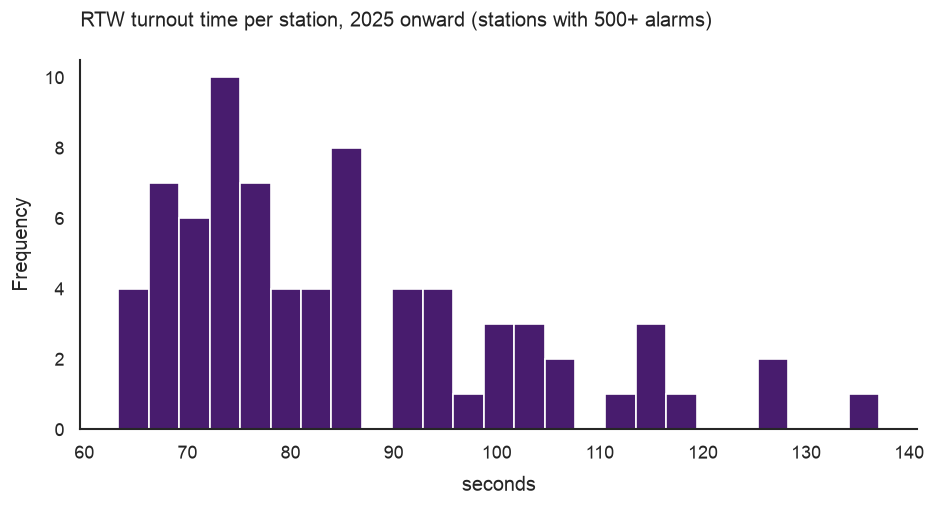

In [10]:
ax = df_st['rtw_turnout_s'].plot(kind='hist', bins=25, figsize=(9, 4), title='RTW turnout time per station, 2025 onward (stations with 500+ alarms)')
ax.set_xlabel('seconds')

### By Quarter of the Year

In [11]:
df_q = q("""
    select right(period, 2) as quarter,
           round(sum(alarm_count_rtw * mean_turnout_seconds_rtw) / sum(alarm_count_rtw), 1) as rtw_turnout_s,
           sum(alarm_count_rtw) as rtw_alarms
    from stg_turnout_times where period_type = 'quarter' and period_end < current_date and alarm_count_rtw > 0 group by 1 order by 1
""")
show_df(df_q)

,quarter,rtw_turnout_s,rtw_alarms
0,q1,84.60,680613.00
1,q2,82.00,646932.00
2,q3,82.20,647823.00
3,q4,84.80,593763.00


## Consistency

Der rollierende Snapshot `current` (30 Tage) sollte nahe am Wert des laufenden Quartals liegen. Vergleich der gewichteten RTW-Zeit:

In [12]:
df_cur = q("""
    select period, min(period_start) as start, max(period_end) as end, sum(alarm_count_rtw) as rtw_alarms,
           round(sum(alarm_count_rtw * mean_turnout_seconds_rtw) / sum(alarm_count_rtw), 1) as rtw_turnout_s
    from stg_turnout_times where period in ('2026_q2', '2026_q3', '2026_q4', 'current') group by 1 order by 2, 1
""")
show_df(df_cur)

,period,start,end,rtw_alarms,rtw_turnout_s
0,2026_q2,2026-04-01 00:00:00,2026-06-30 00:00:00,48645.00,77.90
1,2026_q3,2026-07-01 00:00:00,2026-09-30 00:00:00,47421.00,77.80
2,current,2026-09-07 00:00:00,2026-10-07 00:00:00,16009.00,78.60
3,2026_q4,2026-10-01 00:00:00,2026-12-31 00:00:00,3677.00,77.70


## Link to Response Time

Die Ausrückdauer ist nur ein Teil der Antwortzeit. Der Anteil lässt sich grob abschätzen, wenn wir die stadtweiten Antwortzeit-Mediane aus den Einsätzen danebenlegen. Die Tabelle ist nur eine Größenordnung, keine Zerlegung: Die Quellen messen verschiedene Mengen (Turnout nur dringliche Einsätze mit Ausrücken, ohne Freiwillige Feuerwehr).

In [13]:
df_share = q("""
    with t as (select year(period_start) as year,
                      sum(alarm_count_rtw * mean_turnout_seconds_rtw) / sum(alarm_count_rtw) as rtw_turnout_s
               from stg_turnout_times where period_type = 'quarter' and period_end < current_date and alarm_count_rtw > 0 group by 1),
         m as (select source_year as year, median(response_time_seconds) as ems_median_s
               from stg_missions where mission_type like 'Rettungsdienst%' group by 1)
    select year, round(rtw_turnout_s, 0) as rtw_turnout_s, round(ems_median_s, 0) as ems_median_response_s,
           round(100 * rtw_turnout_s / ems_median_s, 1) as turnout_pct_of_median
    from t join m using (year) order by year
""")
show_df(df_share)

,year,rtw_turnout_s,ems_median_response_s,turnout_pct_of_median
0,2018,88.00,584.00,15.20%
1,2019,86.00,577.00,14.80%
2,2020,80.00,598.00,13.50%
3,2021,83.00,617.00,13.40%
4,2022,84.00,637.00,13.10%
5,2023,82.00,621.00,13.30%
6,2024,83.00,621.00,13.30%
7,2025,83.00,612.00,13.50%
8,2026,79.00,611.00,13.00%


## Findings

### Content

Ausrückzeiten der Berliner Feuerwehr je Wache und Quartal (2018 bis laufendes Quartal) plus ein rollierender 30-Tage-Snapshot. Je Wache und Fahrzeugtyp (RTW, NEF, LHF, DLK, ELW): Zahl der Alarmierungen und die mittlere Ausrückdauer in Sekunden (Alarmierungsübernahme bis Ausrücken). Es zählen nur dringliche Einsätze, bei denen das Fahrzeug ausgerückt ist, ohne Freiwillige Feuerwehr.

### Usefulness

* **Der Teil der Antwortzeit, den die Wache beeinflusst.** Ausrückzeit und Anfahrt sind getrennte Anteile; hier sehen wir den ersten.
* **Blick auf Wachen:** Unterschiede zwischen Wachen und über die Zeit sind sichtbar, auch wenn wir sie nicht räumlich zuordnen können.
* **Zusätzlicher Beleg für den Definitionsbruch:** Die Alarmierungszahlen folgen derselben Grundgesamtheit "dringlich/kritisch" (siehe Beobachtungen).

### Limits

* **Keine Koordinaten, keine Bezirkszuordnung in dieser Quelle.** Die Wachennummer lässt sich aber mit dem Standort-Datensatz verbinden (siehe `01_exploration_stations`): 77 von 80 Wachen finden ihren Standort.
* **Nur Ausrücken, nicht Anfahrt.** Der größere Teil der Antwortzeit liegt außerhalb dieser Quelle.
* **Strukturelle Lücken:** Nicht jede Wache hat NEF, Drehleiter oder ELW; die Fehlwerte sind Struktur, keine Datenfehler. Die Fahrzeugbestände schwanken über die Jahre leicht.
* **Wachenidentität:** Drei Wachen-IDs tragen zwei Namen; mehrere Wachen sind nur für einzelne Quartale vorhanden (Schließung, Neueröffnung, Umbenennung).
* **Das laufende Quartal ist angebrochen** und mit vollen Quartalen nicht vergleichbar.

### Observations

Stand der Ausführung. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Die Zahl der RTW-Alarmierungen fällt 2025 gegenüber 2024 um rund 29 %. Das entspricht dem Rückgang der "kritischen" Einsätze in den Regionaldaten. Auch hier ist die Grundgesamtheit eng gefasst – derselbe Bruch, eine zweite Quelle | By Year and Vehicle Type |
| Die mittlere RTW-Ausrückzeit sinkt von rund 88 s (2018) auf rund 80 bis 83 s (ab 2020), 2026 rund 79 s | By Year and Vehicle Type |
| Drehleiter ist am langsamsten, NEF und RTW am schnellsten; DLK und LHF werden schneller | By Year and Vehicle Type |
| Die Ausrückzeit macht grob 13 bis 15 % des Medians der Antwortzeit aus (Größenordnung, nicht zerlegt) | Link to Response Time |
| Zwischen Wachen liegt die RTW-Ausrückzeit zwischen rund 63 s und rund 137 s. Am langsamsten sind Falkenberg, Wartenberg, Tegelort, Marzahn und Schieritz/Prenzlauer Berg (also nicht nur Randlagen), am schnellsten zum Beispiel Siemensstadt, Tempelhof, Lichterfelde und Tegel. Ursache nicht geprüft | Between Stations |
| Winterquartale (q1, q4) sind etwa 2 bis 3 s langsamer als q2/q3 | By Quarter of the Year |
| Der 30-Tage-Snapshot (`current`) liegt nahe am laufenden Quartal | Consistency |

### Open Questions

* **`02_preparation`:** Wachen-Stammdaten (ID, aktueller Name, Typ) als Seed `seed_stations` führen und Namensvarianten vereinheitlichen. Laufendes Quartal mit Kennzeichen `is_partial` markieren (derzeit gefiltert nur in der Auswertung).
* **Anreicherung:** Wachen-Koordinaten sind mit dem Standort-Datensatz da (`01_exploration_stations`); offen bleiben drei Wachen ohne Standort (zwei neu seit 2026, eine 2023 aufgegeben).
* **`03_analysis_geo`:** Hängt die Ausrückzeit einer Wache an ihrer Auslastung (Alarmierungen) oder an ihrer Lage? Mit den Koordinaten aus dem Standort-Datensatz prüfbar.
* **`03_analysis_special_events`:** Die Alarmzahlen 2025 gegen die Definitionsänderung stellen; sie sind ein zweiter Beleg, kein Beweis.